In [149]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [161]:
con = sqlite3.connect('../../datasets/checking-logs.sqlite')
query_ch = '''
SELECT uid, datetime(timestamp) as "datetime" FROM checker
WHERE uid NOT LIKE '%admin%'
'''
df_ch = pd.read_sql(query_ch, con)
df_ch['datetime'] = pd.to_datetime(df_ch['datetime'])
df_ch['hour'] = df_ch['datetime'].dt.hour
df_ch['weekday'] = df_ch['datetime'].dt.weekday

con.close()

In [162]:
df_weekday = df_ch.groupby(['weekday', 'uid']).size().unstack(fill_value=0)
df_hour = df_ch.groupby(['hour', 'uid']).size().unstack(fill_value=0)

user_order = df_ch['uid'].value_counts().index
df_weekday = df_weekday[user_order]
df_hour = df_hour[user_order].reindex(range(24), fill_value=0)


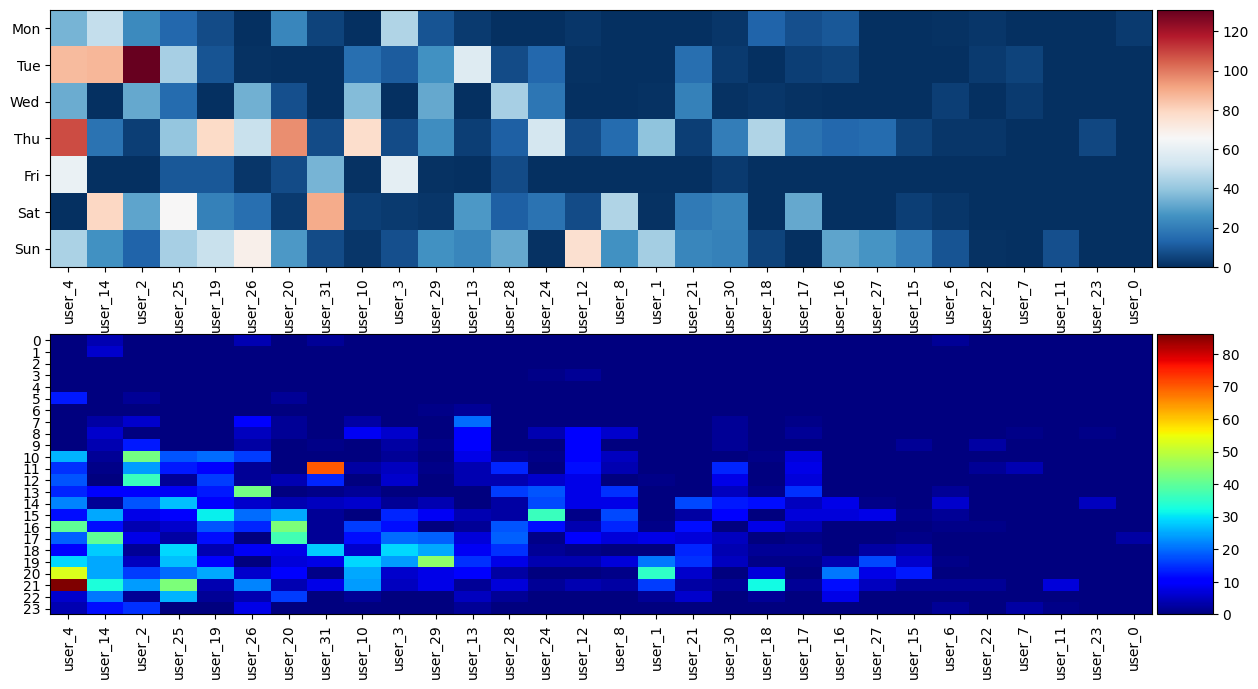

In [163]:
fig, axes = plt.subplots(nrows=2, figsize=(15, 8))

ax1 = axes[0]
im1 = ax1.imshow(df_weekday, aspect='equal', cmap='RdBu_r')

divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, cax=cax1)

ax1.set_yticks(range(7))
ax1.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax1.set_xticks(range(len(user_order)))
ax1.set_xticklabels(user_order, rotation=90)

ax2 = axes[1]
im2 = ax2.imshow(df_hour, aspect='auto', cmap='jet')

divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im2, cax=cax2)

ax2.set_yticks(range(24))
ax2.set_yticklabels(range(24))
ax2.set_xticks(range(len(user_order)))
ax2.set_xticklabels(user_order, rotation=90)

plt.show()

Which user has the most commits on Tue? 
- User_2

Which user has the most commits on Thu?
- User_4

On which weekday do the users not like making a lot of commits?
- Monday

Which user at which hour made the largest number of commits?
- User_4, 21